In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, recall_score, PrecisionRecallDisplay, confusion_matrix, average_precision_score, precision_recall_curve, roc_auc_score, cohen_kappa_score

## Load data

In [5]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,status,province_Gandaki Province,province_Karnali Province,province_Province 1,province_Province 2,province_Province 5,province_Sudoorpaschim Province
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


### Train-test Split

In [6]:
X = df.drop(columns=['status'])
y = df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [7]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2413})
After SMOTE:  Counter({0: 2828, 1: 2828})


# Random Forest

### Simple model

In [8]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

In [9]:
y_pred = rf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3))

Classification Report:
               precision    recall  f1-score   support

           0      0.717     0.734     0.725       707
           1      0.680     0.661     0.670       604

    accuracy                          0.700      1311
   macro avg      0.698     0.697     0.698      1311
weighted avg      0.700     0.700     0.700      1311



### Average Precision Score

In [25]:
y_probas = rf.predict_proba(X_test)[:, 1]
score = average_precision_score(y_test, y_probas)
print(f'Average Precision: {score:.3f}')

Average Precision: 0.746


# Hyperparameter Tuning

In [11]:
params = {
    'n_estimators': [int(x) for x in np.linspace(start=30, stop = 100, num=14)], # number of trees in random forest
    'max_depth': [5, 7], # maximum number of levels in tree
    'min_samples_split': [2, 5], # minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4], # minimum number of samples required at each leaf node
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=params,
    scoring='recall',     
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_sm, y_train_sm)

Fitting 10 folds for each of 168 candidates, totalling 1680 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 7], 'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5],
                         'n_estimators': [30, 35, 40, 46, 51, 56, 62, 67, 73,
                                          78, 83, 89, 94, 100]},
             scoring='recall', verbose=1)

In [12]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best cross-validation recall score: {grid_search.best_score_:.3f}")

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 40}
Best cross-validation recall score: 0.744


In [13]:
rf_tune = grid_search.best_estimator_
y_pred_tune = rf_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_tune, digits=3))

Classification Report:
               precision    recall  f1-score   support

           0      0.723     0.580     0.644       707
           1      0.601     0.740     0.663       604

    accuracy                          0.654      1311
   macro avg      0.662     0.660     0.653      1311
weighted avg      0.667     0.654     0.653      1311



## Average precision

In [26]:
y_probas_tune = rf_tune.predict_proba(X_test)[:, 1]
score = average_precision_score(y_test, y_probas_tune)
print(f'Average Precision: {score:.3f}')

Average Precision: 0.705


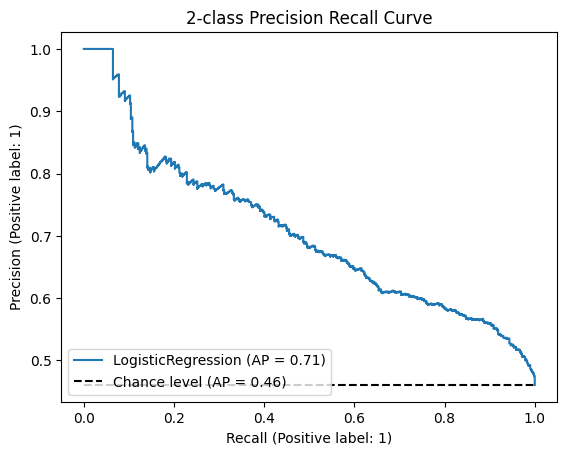

In [15]:
display = PrecisionRecallDisplay.from_estimator(
    rf_tune,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### 

In [16]:
# Recall on base model
y_train_pred = rf.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Base Model): {train_recall:.3f}")

# Recall on tune tune model
y_train_pred = rf_tune.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Tune Model): {train_recall:.3f}")

Recall on Training set (Base Model): 0.992
Recall on Training set (Tune Model): 0.763


### AUC score

In [27]:
auc = roc_auc_score(y_test, y_probas)
print(f"AUC: {auc:.3f}")

auc_tune = roc_auc_score(y_test, y_probas_tune)
print(f"AUC: {auc_tune:.3f}")

AUC: 0.764
AUC: 0.737


### Cohen's Kappa

In [18]:
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.3f}")

kappa_tune = cohen_kappa_score(y_test, y_pred_tune)
print(f"Cohen's Kappa: {kappa_tune:.3f}")

Cohen's Kappa: 0.395
Cohen's Kappa: 0.315


### Confusion matrix

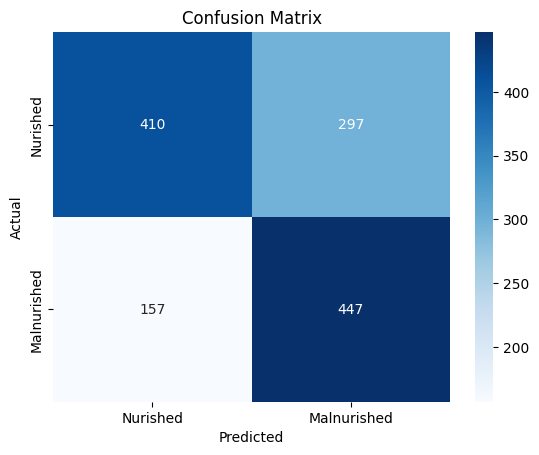

In [19]:
cm = confusion_matrix(y_test, y_pred_tune)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature importance

In [20]:
# Get feature importances
importances = rf_tune.feature_importances_
feature_names = X_train_sm.columns

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Importance (abs)': np.abs(importances)
}).sort_values(by='Importance', ascending=False)

# Display
print(importance_df)

                            Feature  Importance  Importance (abs)
1                      child_weight    0.472934          0.472934
8                      wealth_index    0.134618          0.134618
0                         child_age    0.115594          0.115594
6                  mother_education    0.105563          0.105563
9         province_Gandaki Province    0.031623          0.031623
4                              area    0.028620          0.028620
10        province_Karnali Province    0.028398          0.028398
12              province_Province 2    0.025997          0.025997
11              province_Province 1    0.015195          0.015195
14  province_Sudoorpaschim Province    0.010961          0.010961
5                         child_sex    0.009664          0.009664
7                  health_insurance    0.006845          0.006845
2            diarrhoea_last_2_weeks    0.005534          0.005534
3                fever_last_2_weeks    0.004791          0.004791
13        

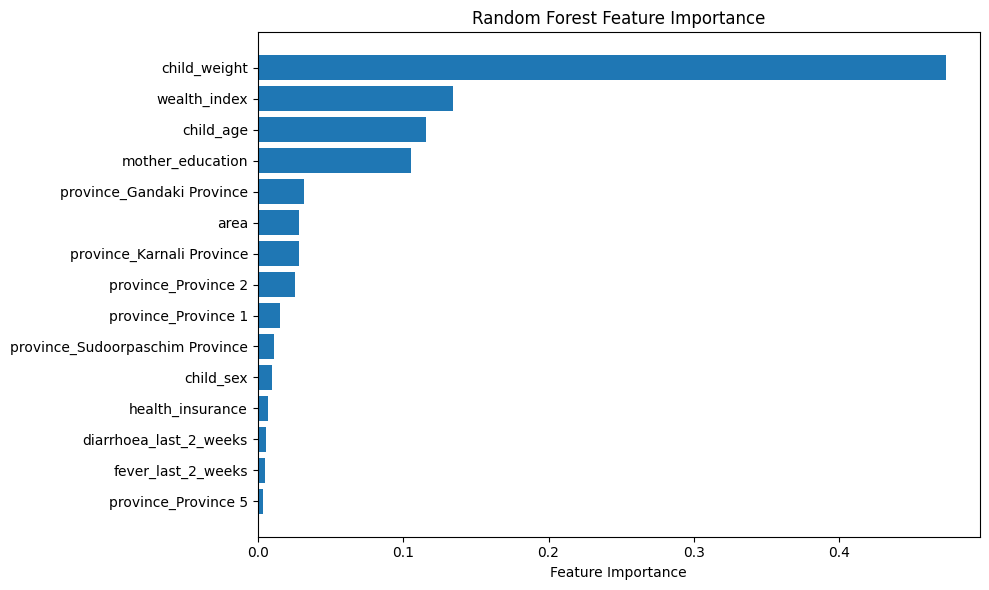

In [21]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Additional

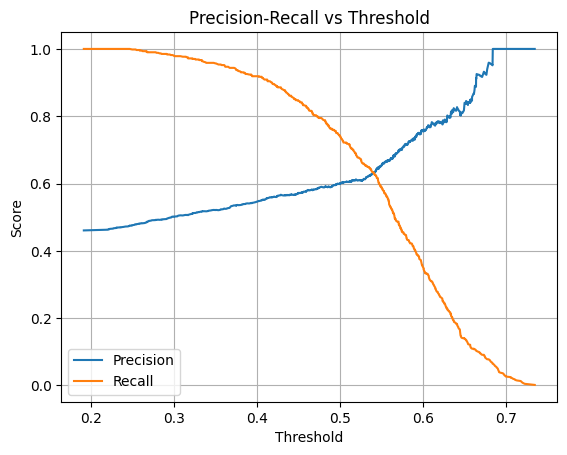

In [22]:
y_probas = rf_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [23]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.83      0.35      0.49       707
           1       0.55      0.92      0.69       604

    accuracy                           0.61      1311
   macro avg       0.69      0.63      0.59      1311
weighted avg       0.70      0.61      0.58      1311


